In [2]:
from pathlib import Path 

import cv2
import dlib
import IPython
import pandas as pd

In [3]:
det = dlib.cnn_face_detection_model_v1('../data/mmod_human_face_detector.dat')

In [4]:
def draw_faces(img, faces):
    for face in faces:
        x, y, w, h = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
        c = face.confidence
        # x, y, w, h = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(img, (x, y), (w, h), (0, 0, 255), 2)

In [5]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [6]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [7]:
def show_detection(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    faces = det(img, upsample_num_times=1)
    draw_faces(img, faces)
    show_image(img)

In [8]:
faces = pd.read_csv('../data/faces.csv', index_col=0)
print(faces.shape)
faces.head()

(1895, 12)


,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080,1920,323,5,919,731,596,726,432696,0.208669,0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080,1920,262,42,614,507,352,465,163680,0.078935,0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,484,389,671,617,187,228,42636,0.020561,0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080,1920,1003,42,1195,261,192,219,42048,0.020278,1
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080,1920,1121,66,1662,824,541,758,410078,0.197761,0


In [9]:
df = pd.read_csv('../data/test_results/dlib.csv', index_col=0)
df = df.groupby(['name', 'face_num']).max()
df = df.reset_index()
print(df.shape)
df.head()

(1203, 14)


,name,face_num,x1,y1,x2,y2,width,height,area,confidence,img_width,img_height,pct_of_frame,id
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,0,530,251,938,659,408,408,166464,1.156534,1920,1080,0.080278,0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,0,239,181,522,464,283,283,80089,1.043341,1920,1080,0.038623,1
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,0,546,450,683,586,137,136,18632,0.667519,1920,1080,0.008985,3
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1,996,109,1110,223,114,114,12996,0.637119,1920,1080,0.006267,3
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,0,1045,296,1534,785,489,489,239121,1.075798,1920,1080,0.115317,4


In [10]:
d = df[['name', 'x1']].groupby('name').count().rename({'x1': 'dlib'}, axis=1)
f = faces[['name', 'x1']].groupby('name').count().rename({'x1': 'faces'}, axis=1)
print(d.shape)
print(f.shape)
cnt_df = f.merge(d,
                 how='left',
                 left_index=True,
                 right_index=True)
cnt_df

(827, 1)
(962, 1)


,faces,dlib
name,,
Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1,1.0
Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1,1.0
Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,2,2.0
Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1,1.0
Billions.S02E01.1080p.BluRay.x265-RARBG_32328.png,1,1.0
...,...,...
Will.&.Grace.S11E17.New.Crib.1080p.Web.h264-JBee_28008.png,1,1.0
fargo.s05e02.2160p.web.h265-successfulcrab-sample_0336.png,2,NaN
fargo.s05e04.2160p.web.h265-successfulcrab_51600.png,1,1.0


In [11]:
missing = cnt_df[cnt_df['dlib'].isna()]
m = missing.index.to_list()
m

['Billions.S04E02.1080p.WEBRip.x265-RARBG_52416.png',
 'Carnivale.S02E03.1080p.WEBRip.10Bit.EAC3.H265-d3g_35616.png',
 'Carnivale.S02E04.1080p.WEBRip.10Bit.EAC3.H265-d3g_20880.png',
 'Carnivale.S02E04.1080p.WEBRip.10Bit.EAC3.H265-d3g_32664.png',
 'Carnivale.S02E11.1080p.WEBRip.10Bit.EAC3.H265-d3g_49632.png',
 'Cheers.S02E01.1080p.BluRay.x265-RARBG_26040.png',
 'Cheers.S05E13.1080p.BluRay.x265-RARBG_19392.png',
 'Cheers.S06E09.1080p.BluRay.x265-RARBG_05688.png',
 'Cheers.S06E09.1080p.BluRay.x265-RARBG_26112.png',
 'Cheers.S09E05.1080p.BluRay.x265-RARBG_23376.png',
 'Cheers.S11E21.1080p.BluRay.x265-RARBG_22272.png',
 'For.All.Mankind.S01E03.1080p.WEBRip.x265-RARBG_51744.png',
 'Frasier.S01E02.Space.Quest.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_15360.png',
 'Frasier.S02E05.Dukes.We.Hardly.Knew.Ye.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_31704.png',
 'Frasier.S03E07.The.Adventures.of.Bad.Boy.and.Dirty.Girl.2.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_28392.png',
 'Frasier.S03E21.Where.Theres.S

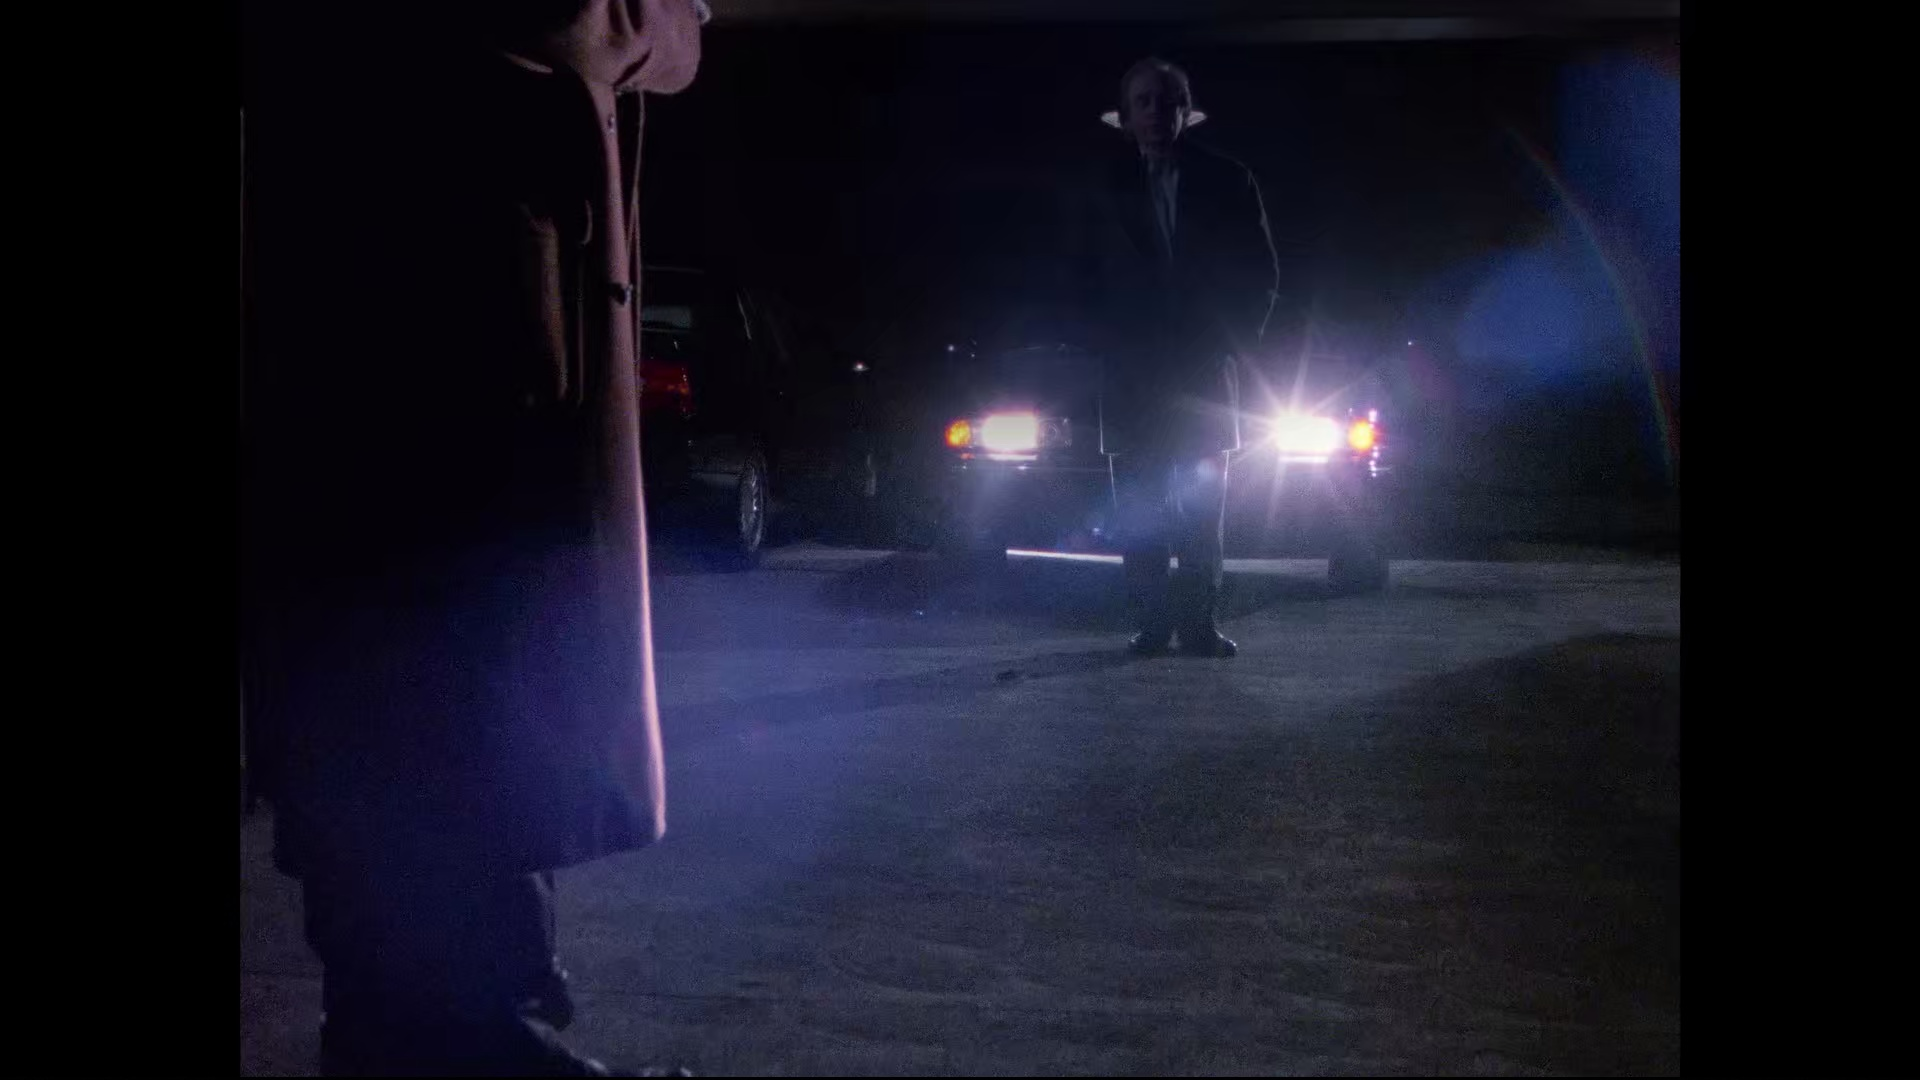

In [14]:
show_by_name(m[17])

In [15]:
m[17]

'Frasier.S04E11.Three.Days.of.the.Condo.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_14688.png'

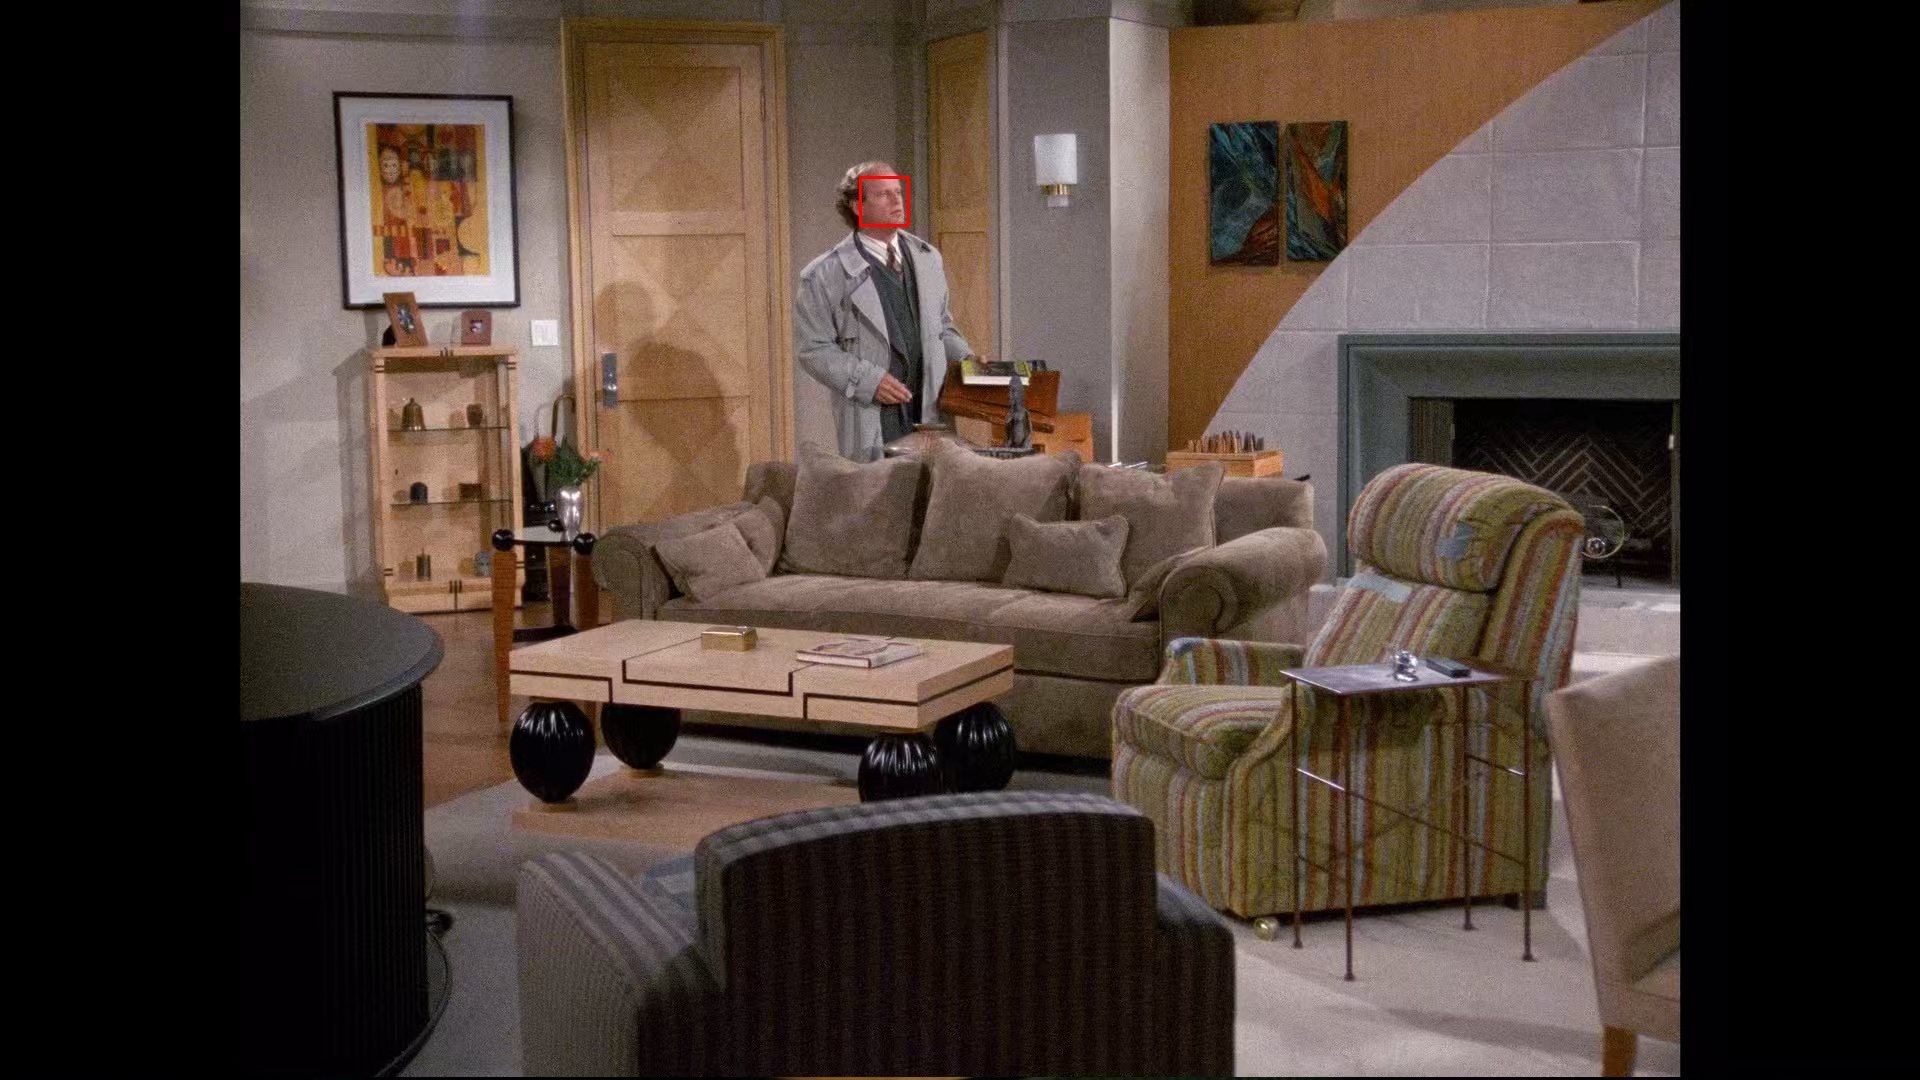

In [13]:
show_detection(name)